# Práctica 3 — Reconocimiento facial con red neuronal convolucional (CNN)

**Objetivo de esta práctica:** pasar de datos tabulares (Iris, Wine) a **imágenes**. Se usa el dataset `fetch_lfw_people` (fotos de caras de personas famosas) para entrenar una CNN que reconozca a qué persona pertenece cada foto.

Es el primer contacto con capas convolucionales (`Conv2D`, `MaxPooling2D`) y con el flujo típico para imágenes: cargar → explorar visualmente → aplanar con `Flatten` → clasificar con `Dense` + `softmax`.

## 1. Importar librerías

In [1]:
import tensorflow as tf                                     # TensorFlow: para construir y entrenar la red neuronal
import matplotlib.pyplot as plt                             # Para visualizar las imágenes del dataset
from sklearn.datasets import fetch_lfw_people                # Dataset de rostros (Labeled Faces in the Wild)
from sklearn.model_selection import train_test_split        # Divide los datos en entrenamiento y prueba


## 2. Cargar el dataset de rostros

`min_faces_per_person=70` filtra el dataset para quedarse solo con personas que tengan al menos 70 fotos (así hay suficientes ejemplos por persona para entrenar). `resize=0.7` reduce el tamaño de las imágenes al 70% para que el entrenamiento sea más rápido.

In [2]:
data = fetch_lfw_people(min_faces_per_person=70, resize=0.7)   # Carga solo personas con 70+ fotos, imágenes reducidas al 70%
x, y = data.images[..., None], data.target                     # x: las imágenes (se agrega una dimensión extra al final para el canal de color)
n_class = len(data.target_names)                               # Cantidad de personas distintas (clases) en el dataset
print("cantidad de personas", n_class)


cantidad de personas 7


### Nota simple: ¿qué hace `[..., None]`?

`data.images` viene como (cantidad_fotos, alto, ancho) — imágenes en escala de grises sin un canal de color explícito. Keras espera un canal al final (alto, ancho, canales), así que `[..., None]` agrega ese canal extra (1 canal = escala de grises, en vez de 3 como sería en imágenes a color).

## 3. Ver una imagen del dataset

(87, 65, 1)


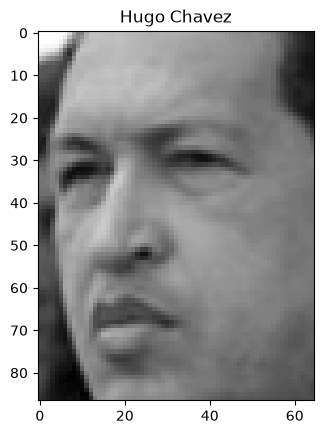

In [3]:
plt.imshow(x[0], cmap="gray")            # Muestra la primera imagen del dataset, en escala de grises
plt.title(data.target_names[y[0]])        # El título de la imagen es el nombre de la persona (usando su etiqueta y[0])
print(x[0].shape)                         # Forma de la imagen: (alto, ancho, canales) -> el último número es el canal de color


## 4. Ver otra imagen distinta, para comparar

Text(0.5, 1.0, 'George W Bush')

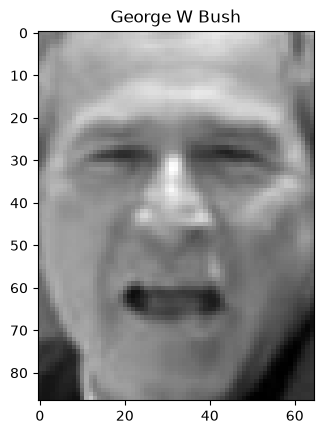

In [4]:
plt.imshow(x[10], cmap="gray")           # Muestra la imagen número 10
plt.title(data.target_names[y[10]])       # Su nombre correspondiente


## 5. Ver varias imágenes juntas (mosaico de 16 fotos)

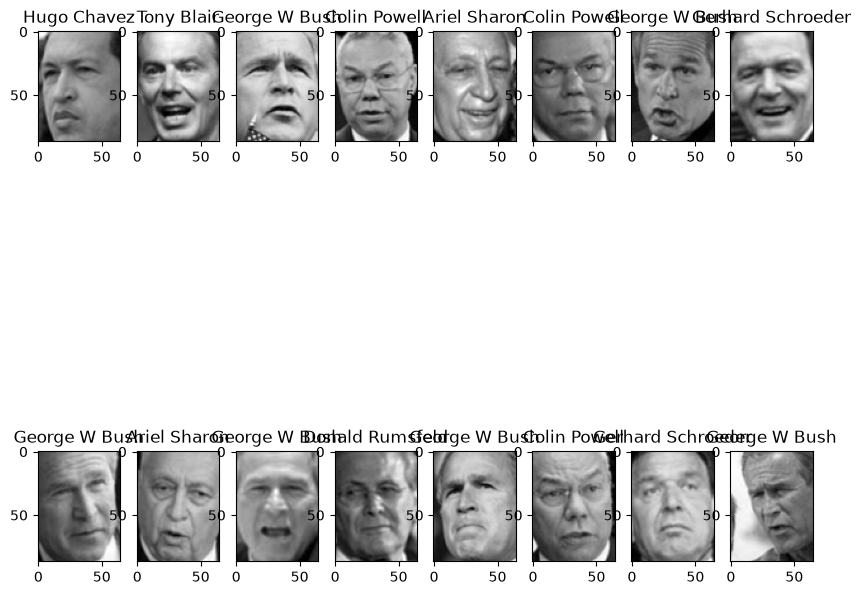

In [5]:
plt.figure(figsize=(10,10))                  # Tamaño de la figura completa
for i in range(16):                          # Recorre las primeras 16 imágenes del dataset
  plt.subplot(2,8,i+1)                       # Ubica cada imagen en una cuadrícula de 2 filas x 8 columnas
  plt.imshow(x[i], cmap="gray")              # Dibuja la imagen i
  plt.title(data.target_names[y[i]])         # Con el nombre de la persona como título


## 6. Revisar la forma de los datos (`shape`)

Entender el `.shape` es clave para trabajar con imágenes: el primer número es cuántas fotos hay, y los siguientes describen cada foto individual (alto, ancho, canales).

In [6]:
x.shape        # (1288, 87, 65, 1) -> 1288 imágenes, cada una de 87 x 65 píxeles, con 1 canal (escala de grises)


(1288, 87, 65, 1)

In [7]:
x.shape[1:]    # Se queda solo con la forma de UNA imagen (sin contar cuántas hay) -> (87, 65, 1)
               # Esto es justo lo que se necesita para el Input(shape=...) del modelo mas adelante


(87, 65, 1)

## 7. Separar entrenamiento y prueba

In [8]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42     # 20% para prueba, 80% para entrenar
)


## 8. Construir el modelo (red neuronal convolucional)

Arquitectura: dos bloques `Conv2D` + `MaxPooling2D` (extraen características visuales y reducen el tamaño de la imagen), luego `Flatten` (convierte la imagen 2D en un vector 1D), y finalmente dos capas `Dense` para clasificar entre las `n_class` personas.

In [9]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=x.shape[1:]),                # Entrada: una imagen de (87, 65, 1)

    tf.keras.layers.Conv2D(32, 3, activation="relu"),        # 1er bloque convolucional: 32 filtros de 3x3, detecta patrones simples (bordes, texturas)
    tf.keras.layers.MaxPooling2D(),                          # Reduce el tamaño de la imagen a la mitad, quedándose con lo más importante

    tf.keras.layers.Conv2D(64, 3, activation="relu"),        # 2do bloque convolucional: 64 filtros, detecta patrones más complejos combinando los anteriores
    tf.keras.layers.MaxPooling2D(),                          # Vuelve a reducir el tamaño

    tf.keras.layers.Flatten(),                               # Aplana la imagen (que ya es 2D con varios canales) en un solo vector 1D,
                                                              # porque las capas Dense que siguen no aceptan datos en forma de imagen directamente
    tf.keras.layers.Dense(128, activation="relu"),           # Capa densa de 128 neuronas para combinar todas las características detectadas
    tf.keras.layers.Dense(n_class, activation="softmax"),    # Capa de salida: una neurona por persona, softmax = probabilidad de cada una
])
model.summary()     # Imprime una tabla con cada capa, su forma de salida y cuántos parámetros (pesos) tiene


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 85, 63, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 42, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 40, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 20, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 17920)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,293,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,313,607 (8.83 MB)

 Trainable params: 2,313,607 (8.83 MB)

 Non-trainable params: 0 (0.00 B)

## 9. Compilar el modelo

Igual que en Iris y Wine: `sparse_categorical_crossentropy` porque `y` son números enteros (una etiqueta por persona), no vectores one-hot.

In [10]:
model.compile(
    optimizer="adam",                              # Optimizador estándar para ajustar los pesos
    loss="sparse_categorical_crossentropy",        # Pérdida para clasificación multiclase con etiquetas enteras
    metrics=["accuracy"]                           # Queremos ver el % de aciertos durante el entrenamiento
)


## 10. Entrenar el modelo

Esta primera versión entrena directo, sin `validation_split` ni `EarlyStopping` ni revisar el balance de clases. Es intencional: es el punto de partida de la práctica, antes de aprender a diagnosticar problemas de entrenamiento (por ejemplo, si el modelo se estanca porque hay muchas más fotos de una persona que de las demás).

In [11]:
model.fit(
    x_train, y_train,
    epochs=15              # Entrena durante 15 vueltas completas sobre los datos de entrenamiento
)


Epoch 1/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.3728 - loss: 1.7577
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.4388 - loss: 1.5661
Epoch 3/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.5718 - loss: 1.2453
Epoch 4/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.7330 - loss: 0.8221
Epoch 5/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.8204 - loss: 0.5624
Epoch 6/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.8893 - loss: 0.3886
Epoch 7/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.9194 - loss: 0.2671
Epoch 8/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.9524 - loss: 0.1904
Epoch 9/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - accuracy: 0.9544 - loss: 0.1588
Epoch 10/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.9835 - loss: 0.0849
Epoch 11/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.9922 - loss: 0.0528
Epoch 12/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy:

## 11. Probar el modelo con una foto de prueba

Se toma UNA foto del set de prueba (la número 20) y se le pide al modelo que prediga quién es. `argmax(1)` elige la persona con mayor probabilidad de softmax, igual que en Iris y Wine.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
Salida de softmax [1]
Nombre ['Colin Powell']


Text(0.5, 1.0, 'Colin Powell')

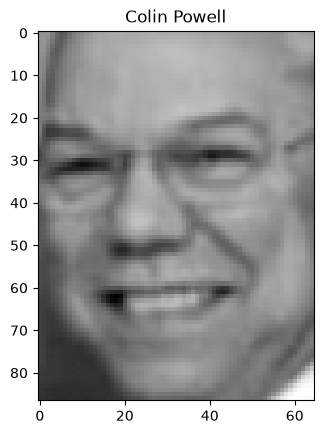

In [12]:
prediccion = model.predict(x_test[[20]]).argmax(1)     # Predice sobre la imagen 20 del set de prueba (entre corchetes dobles para mantenerla en forma de lote)
print("Salida de softmax", prediccion)                 # Índice de la clase que el modelo eligió como más probable
print("Nombre", data.target_names[prediccion])          # Convierte ese índice al nombre real de la persona
plt.imshow(x_test[20], cmap="gray")                     # Muestra la imagen que se le pidió predecir
plt.title(data.target_names[y_test[20]])                # Título con el nombre REAL, para comparar contra la predicción


## 12. Conclusión de esta práctica

Con solo 15 épocas y sin ajustes adicionales, el modelo ya llega a un accuracy alto en entrenamiento porque aprende a reconocer patrones visuales característicos de cada persona (Conv2D + MaxPooling2D). Sin embargo, esta versión no mide qué tan bien generaliza a datos nuevos durante el entrenamiento (no hay `validation_split`), y no corrige el desbalance de clases (algunas personas tienen muchas más fotos que otras en `fetch_lfw_people`). Esos dos puntos son justamente los que se trabajan en la siguiente etapa de la práctica, agregando `class_weight`, `validation_split`, `EarlyStopping` y capas de regularización (`BatchNormalization`, `Dropout`).